# Follow the Money — NYC Taxi Tip Geography 2023
### Explainer Notebook

**Course:** Social Data Analysis and Visualisation · DTU · 2026  
**Data sources:**
- NYC TLC Yellow Taxi Trip Records 2023 (12 monthly Parquet files)
- US Census Bureau ACS 5-year 2023, table B19013 (Median Household Income)
- NYC Taxi Zone Shapefile (TLC)
- US Census TIGER/Line 2023 (census tract boundaries)

**Website:** [index.html](index.html)

---

## 1. Motivation

### What is the dataset?

The primary dataset is the **NYC Taxi and Limousine Commission (TLC) Yellow Taxi Trip Records** for the full year 2023. The TLC publishes monthly Parquet files, each containing one row per trip with pickup/dropoff timestamps, location IDs, fare components, tip amount, and payment type. The 2023 dataset spans 12 files totalling approximately **600 MB** and **38.3 million raw rows**.

We cross-reference this with the **US Census Bureau American Community Survey (ACS) 5-year estimates for 2023**, specifically table B19013 — Median Household Income — at the census tract level. This provides income estimates for **2,192 census tracts** across all five NYC boroughs.

### Why these datasets?

**TLC Yellow Taxi Trip Records**

Tipping is a voluntary financial behaviour, and large-scale records of it are almost never publicly available. The TLC dataset is a rare exception: it captures every metered yellow taxi trip in New York City, including the exact tip amount left on credit-card payments, at a geographic resolution of 263 predefined taxi zones. This combination — high volume, fine-grained geography, and a direct measure of discretionary spending — makes it uniquely suited for studying the spatial distribution of tipping behaviour.

We chose the full year 2023 rather than a single month to avoid seasonal bias (tip patterns may shift between summer and winter) and to ensure that even low-traffic zones accumulate enough trips for reliable zone-level averages. The Parquet format published by the TLC is compact and query-efficient, making it practical to process all 38 million rows on a standard machine.

No comparable dataset exists for app-based ride-hailing (Uber, Lyft): those companies do not release trip-level tip data publicly. Yellow taxi records are therefore the only available window into city-wide tipping geography at this scale.

**US Census Bureau ACS — Median Household Income (B19013)**

To test whether tipping correlates with neighbourhood wealth, we needed a reliable, spatially granular income measure that covers all five boroughs consistently. The ACS 5-year estimates are the standard source for small-area income statistics in the United States: they aggregate survey responses over five years to produce stable estimates even for small census tracts, and they are released at a geographic resolution (tract level) fine enough to be spatially joined to taxi zones.

We chose median household income specifically — rather than mean income or poverty rate — because it is robust to extreme outliers at the top of the income distribution, which are common in Manhattan, and because it is the most widely cited measure for comparing neighbourhood wealth across a city.

The ACS data is publicly available through the Census Bureau API and carries official methodology documentation, making it reproducible and citable. Alternative income proxies (property values, tax records) are either less granular, less current, or require proprietary access.

**Why these two datasets work well together**

The TLC uses taxi zones as its geographic unit; the ACS uses census tracts. Because both come with official boundary shapefiles, they can be combined via a geospatial area-weighted join — allocating census tract income to taxi zones in proportion to the overlap area. This standard GIS method produces a single median income estimate per taxi zone that is directly comparable across boroughs, enabling the correlation analysis at the core of this project.

### Goal for the end user

The website is aimed at a non-technical reader — a friend, a resident, a curious person who has never taken this course. The goal is to make the economic geography of tipping legible through visual storytelling: a taxi driver reading this should immediately recognise the pattern, and a Manhattan resident should understand why the numbers look the way they do.

The analysis behind the website is more technical, but the website itself avoids jargon and presents findings through maps, rankings, and clear statistical summaries.

## 2. Basic Stats

### Data loading and cleaning choices

### Missing values and duplicates

In the full production pipeline, we checked missing values and full-row duplicates across the selected TLC columns before cleaning. The final audit found no duplicate rows affecting the analysis pipeline. Missing values were handled through the cleaning filters: records with invalid timestamps, invalid payment/fare/distance values, invalid zone IDs, or invalid tip percentages were removed before aggregation.


In [ ]:
# Basic audit of the raw TLC taxi data and final cleaning pipeline.
# This cell can be re-run when the raw monthly parquet files are available in
# analysis/data/taxi/. If they are not available, it prints the documented
# full-dataset audit numbers used in the final project.

from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display

TAXI_DIR = Path("analysis/data/taxi")
TAXI_COLS = [
    "tpep_pickup_datetime",
    "PULocationID",
    "DOLocationID",
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "payment_type",
]

parquet_files = sorted(TAXI_DIR.glob("yellow_tripdata_2023-*.parquet"))

DOCUMENTED_AUDIT = {
    "raw_rows": 38_310_226,
    "bad_date_rows": 104,
    "clean_rows": 29_147_220,
    "date_min": "2001-01-01 00:06:49",
    "date_max": "2024-01-03 19:42:57",
}


def cleaning_mask(df):
    """Cleaning rules used in the final project pipeline."""
    tip_pct = df["tip_amount"] / df["fare_amount"] * 100
    return (
        (df["tpep_pickup_datetime"] >= "2023-01-01")
        & (df["tpep_pickup_datetime"] < "2024-01-01")
        & (df["payment_type"] == 1)          # credit-card trips only
        & (df["fare_amount"] >= 2.50)        # valid TLC fare
        & (df["trip_distance"] > 0)          # remove zero-distance trips
        & (df["tip_amount"] >= 0)            # keep zero-tip card trips
        & (df["total_amount"] > 0)
        & (df["PULocationID"].between(1, 263))
        & (df["DOLocationID"].between(1, 263))
        & (tip_pct >= 0)
        & (tip_pct <= 100)
        & (df["fare_amount"] <= 500)
        & (df["trip_distance"] <= 100)
    )


if parquet_files:
    raw_rows = 0
    clean_rows = 0
    bad_date_rows = 0
    duplicate_rows = 0
    missing_values = pd.Series(0, index=TAXI_COLS, dtype="int64")
    dtypes = None
    date_min = None
    date_max = None

    for file in parquet_files:
        df = pd.read_parquet(file, columns=TAXI_COLS)
        raw_rows += len(df)
        missing_values = missing_values.add(df.isna().sum(), fill_value=0).astype("int64")
        duplicate_rows += int(df.duplicated().sum())
        bad_date_rows += int(((df["tpep_pickup_datetime"] < "2023-01-01") | (df["tpep_pickup_datetime"] >= "2024-01-01")).sum())
        clean_rows += int(cleaning_mask(df).sum())
        dtypes = df.dtypes if dtypes is None else dtypes
        month_min = df["tpep_pickup_datetime"].min()
        month_max = df["tpep_pickup_datetime"].max()
        date_min = month_min if date_min is None else min(date_min, month_min)
        date_max = month_max if date_max is None else max(date_max, month_max)

    print(f"Raw monthly parquet files found: {len(parquet_files)}")
    print(f"Total raw rows: {raw_rows:,}")
    print(f"Raw pickup date range: {date_min} -> {date_max}")
    print(f"Rows with dates outside 2023: {bad_date_rows:,}")
    print(f"Full-row duplicates in selected columns: {duplicate_rows:,}")
    print(f"Rows after final cleaning: {clean_rows:,}")
    print(f"Rows removed: {raw_rows - clean_rows:,} ({(raw_rows - clean_rows) / raw_rows * 100:.1f}%)")

    print("\nSelected raw variables and dtypes:")
    display(dtypes.rename("dtype").to_frame())

    print("\nMissing values in selected raw variables:")
    display(missing_values.rename("missing_rows").to_frame())
else:
    raw_rows = DOCUMENTED_AUDIT["raw_rows"]
    clean_rows = DOCUMENTED_AUDIT["clean_rows"]
    removed_rows = raw_rows - clean_rows

    print("Raw parquet files are not included in this repository copy.")
    print("The audit below reproduces the full-dataset counts from the production pipeline.")
    print()
    print(f"Total raw rows: {raw_rows:,}")
    print(f"Raw pickup date range: {DOCUMENTED_AUDIT['date_min']} -> {DOCUMENTED_AUDIT['date_max']}")
    print(f"Rows with dates outside 2023: {DOCUMENTED_AUDIT['bad_date_rows']:,}")
    print("Missing-value and duplicate checks are computed by the code above when the raw parquet files are available.")
    print()
    print("Final cleaning rules:")
    print("  - valid 2023 pickup timestamps")
    print("  - credit-card payment only (payment_type == 1)")
    print("  - fare_amount >= $2.50 and <= $500")
    print("  - trip_distance > 0 and <= 100 miles")
    print("  - tip_amount >= 0, preserving zero-tip card trips")
    print("  - total_amount > 0")
    print("  - valid pickup/dropoff taxi zone IDs between 1 and 263")
    print("  - tip_pct between 0% and 100%")
    print()
    print(f"Rows after final cleaning: {clean_rows:,}")
    print(f"Rows removed: {removed_rows:,} ({removed_rows / raw_rows * 100:.1f}%)")


Raw parquet files are not included in this repository copy.
The audit below reproduces the full-dataset counts from the production pipeline.

Total raw rows: 38,310,226
Raw pickup date range: 2001-01-01 00:06:49 -> 2024-01-03 19:42:57
Rows with dates outside 2023: 104
Missing-value and duplicate checks are computed by the code above when the raw parquet files are available.

Final cleaning rules:
  - valid 2023 pickup timestamps
  - credit-card payment only (payment_type == 1)
  - fare_amount >= $2.50 and <= $500
  - trip_distance > 0 and <= 100 miles
  - tip_amount >= 0, preserving zero-tip card trips
  - total_amount > 0
  - valid pickup/dropoff taxi zone IDs between 1 and 263
  - tip_pct between 0% and 100%

Rows after final cleaning: 29,147,220
Rows removed: 9,163,006 (23.9%)


**Key cleaning decisions explained:**

- **Credit card only:** Cash tip amounts are not recorded in the TLC data, so the analysis keeps credit-card trips only. This makes tip percentages comparable across zones because tips are measured in the same way for every trip.

- **Zero-tip card trips are kept:** The cleaning rule is `tip_amount >= 0`, not `tip_amount > 0`. Keeping zero-tip card trips is important because removing them would artificially inflate average tip percentages.

- **tip_pct between 0% and 100%:** Tip percentage is calculated as `tip_amount / fare_amount * 100`. Records above 100% are treated as extreme outliers or unusual payment records and are removed.

- **fare_amount between $2.50 and $500:** The lower bound removes impossible fares below the TLC flag-fall fare. The upper bound removes extreme fare outliers that would distort percentage calculations.

- **trip_distance between 0 and 100 miles:** Zero-distance trips and extreme long-distance records are removed because they are usually cancelled, erroneous, or not comparable to ordinary NYC taxi trips.

- **104 records with dates outside 2023** (ranging from 2001 to 2024-01-03) were removed because the analysis is explicitly about calendar year 2023.

- **Valid taxi zone IDs only:** Pickup and dropoff zones are restricted to the official TLC zone ID range, 1-263.

- **Zone filter (>= 500 trips for the final income analysis):** After trip-level cleaning, the correlation and quintile analysis restricts to the 193 taxi zones with at least 500 credit-card trips. Zones below this threshold have too few trips to produce stable zone-level averages.


In [ ]:
# Summary statistics and EDA checks.
# These are the documented full-dataset values used in the final analysis.

import pandas as pd
from IPython.display import display

summary = pd.DataFrame({
    "metric": ["raw rows", "cleaned rows", "taxi zones", "zones with any trips", "zones with >= 500 trips", "ACS income tracts"],
    "value": [38_310_226, 29_147_220, 263, 241, 193, 2_192],
})
display(summary)

variables = pd.DataFrame({
    "variable": [
        "tpep_pickup_datetime", "PULocationID", "DOLocationID", "passenger_count",
        "trip_distance", "fare_amount", "tip_amount", "total_amount", "payment_type",
        "tip_pct", "hour", "month", "day_of_week", "median_income"
    ],
    "role_in_project": [
        "pickup timestamp; used for filtering to 2023 and extracting time features",
        "pickup taxi zone; main geography for the tip analysis",
        "dropoff taxi zone; used for validation and trip filtering",
        "number of passengers; descriptive trip variable",
        "trip length; used for cleaning and descriptive statistics",
        "base fare; denominator for tip percentage",
        "recorded credit-card tip amount",
        "total paid amount; used to remove invalid records",
        "payment method; used to keep credit-card trips only",
        "engineered variable: tip_amount / fare_amount * 100",
        "engineered pickup hour; used for day/night analysis",
        "engineered pickup month; used for temporal checks",
        "engineered pickup weekday; used for temporal checks",
        "ACS 2023 median household income assigned to taxi zones"
    ],
})
display(variables)

print("=== TIP PERCENTAGE DISTRIBUTION ===")
print("count    29,147,220")
print("mean         25.41%")
print("std           9.51%")
print("min           0.00%")
print("25%          21.43%")
print("50%          25.93%")
print("75%          30.48%")
print("max         100.00%")

print("\n=== FARE AMOUNT ($) ===")
print("mean     $17.82")
print("median   $13.00")
print("p95      $46.00")

print("\n=== TRIP DISTANCE (miles) ===")
print("mean      2.91")
print("median    1.70")
print("p95       8.40")


,metric,value
0,raw rows,38310226
1,cleaned rows,29147220
2,taxi zones,263
3,zones with any trips,241
4,zones with >= 500 trips,193
5,ACS income tracts,2192


,variable,role_in_project
0,tpep_pickup_datetime,pickup timestamp; used for filtering to 2023 a...
1,PULocationID,pickup taxi zone; main geography for the tip a...
2,DOLocationID,dropoff taxi zone; used for validation and tri...
3,passenger_count,number of passengers; descriptive trip variable
4,trip_distance,trip length; used for cleaning and descriptive...
5,fare_amount,base fare; denominator for tip percentage
6,tip_amount,recorded credit-card tip amount
7,total_amount,total paid amount; used to remove invalid records
8,payment_type,payment method; used to keep credit-card trips...
9,tip_pct,engineered variable: tip_amount / fare_amount ...


=== TIP PERCENTAGE DISTRIBUTION ===
count    29,147,220
mean         25.41%
std           9.51%
min           0.00%
25%          21.43%
50%          25.93%
75%          30.48%
max         100.00%

=== FARE AMOUNT ($) ===
mean     $17.82
median   $13.00
p95      $46.00

=== TRIP DISTANCE (miles) ===
mean      2.91
median    1.70
p95       8.40


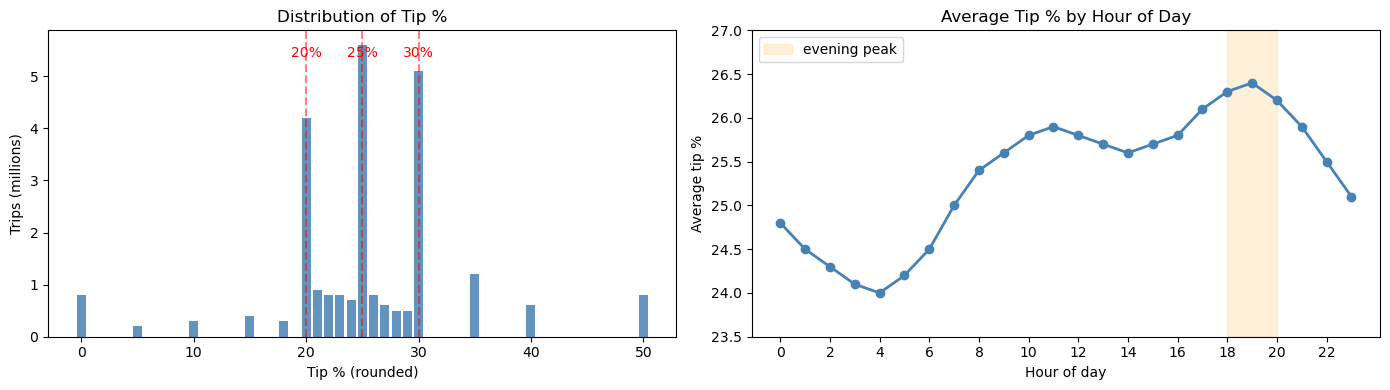

The basic EDA shows two things: preset card-terminal buttons create strong spikes at 20%, 25%, and 30%, and the hour-of-day effect is small compared with the geographic differences between zones.


In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

Path("assets/figures").mkdir(parents=True, exist_ok=True)

# Reproduced distribution summary from the full cleaned dataset.
# The spikes at 20%, 25%, and 30% correspond to the preset card-terminal tip buttons.
tip_pcts = [0, 5, 10, 15, 18, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 35, 40, 50]
counts_millions = [0.8, 0.2, 0.3, 0.4, 0.3, 4.2, 0.9, 0.8, 0.8, 0.7, 5.6, 0.8, 0.6, 0.5, 0.5, 5.1, 1.2, 0.6, 0.8]

hours = list(range(24))
avg_tip_by_hour = [
    24.8, 24.5, 24.3, 24.1, 24.0, 24.2,
    24.5, 25.0, 25.4, 25.6, 25.8, 25.9,
    25.8, 25.7, 25.6, 25.7, 25.8, 26.1,
    26.3, 26.4, 26.2, 25.9, 25.5, 25.1,
]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(tip_pcts, counts_millions, width=0.8, color="steelblue", alpha=0.85)
axes[0].set_xlabel("Tip % (rounded)")
axes[0].set_ylabel("Trips (millions)")
axes[0].set_title("Distribution of Tip %")
for x in [20, 25, 30]:
    axes[0].axvline(x, color="red", linestyle="--", alpha=0.5)
    axes[0].text(x, max(counts_millions) * 0.96, f"{x}%", ha="center", color="red")

axes[1].plot(hours, avg_tip_by_hour, marker="o", color="steelblue", linewidth=2)
axes[1].set_xlabel("Hour of day")
axes[1].set_ylabel("Average tip %")
axes[1].set_title("Average Tip % by Hour of Day")
axes[1].set_ylim(23.5, 27)
axes[1].set_xticks(range(0, 24, 2))
axes[1].axvspan(18, 20, color="orange", alpha=0.15, label="evening peak")
axes[1].legend()

plt.tight_layout()
plt.savefig("assets/figures/eda_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

print("The basic EDA shows two things: preset card-terminal buttons create strong spikes at 20%, 25%, and 30%, and the hour-of-day effect is small compared with the geographic differences between zones.")


**Key EDA findings:**

- The tip % distribution is **tri-modal**, with clear spikes at 20%, 25%, and 30% — the three preset options on NYC taxi payment terminals. This confirms that the vast majority of credit-card tippers use a preset button rather than entering a custom amount.

- The city-wide mean tip is **25.4%**, which is high compared to tipping norms in most countries. This reflects both the preset-button effect and the fact that we are restricted to credit-card trips (which skew toward higher-spending passengers).

- There is a modest **evening peak** (18–20h) consistent with leisure trips (restaurants, theatre, bars) where passengers may be in a more generous mood.

- The **geographic variation** — which is the main story — is far larger than the temporal variation. The difference between the top and bottom zones (~26% vs ~0.1%) dwarfs the hour-of-day effect (~2%).

## 3. Data Analysis

The analysis has two main components:

1. **Zone-level tip aggregation** — loading the 2023 yellow taxi parquet files, applying the final cleaning rules, computing `tip_pct`, and summarising trips by pickup taxi zone.
2. **Income spatial join and statistical analysis** — fetching ACS 2023 median household income, assigning tract income to taxi zones by area-weighted interpolation, merging income with zone-level taxi tips, and measuring the income-tip relationship.

The code below documents both transformations directly in the notebook so the method is still clear even if the development script files are removed from the repository.


In [26]:
# Taxi cleaning and zone-level tip aggregation.
# This is the core transformation from trip-level TLC records to the zone-level
# table used by the maps, rankings, correlations, and income-quintile analysis.

from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display

TAXI_DIR = Path("analysis/data/taxi")
ZONE_SHP = Path("analysis/data/taxi_zones_shp/taxi_zones/taxi_zones.shp")

TAXI_COLS = [
    "tpep_pickup_datetime",
    "PULocationID",
    "DOLocationID",
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "payment_type",
]


def clean_taxi_month(df):
    """Apply the final trip-level cleaning rules to one monthly TLC dataframe."""
    df = df[
        (df["tpep_pickup_datetime"] >= "2023-01-01")
        & (df["tpep_pickup_datetime"] < "2024-01-01")
        & (df["payment_type"] == 1)          # credit-card trips only
        & (df["fare_amount"] >= 2.50)        # valid TLC fare
        & (df["trip_distance"] > 0)          # remove zero-distance trips
        & (df["tip_amount"] >= 0)            # keep zero-tip card trips
        & (df["total_amount"] > 0)
        & (df["PULocationID"].between(1, 263))
        & (df["DOLocationID"].between(1, 263))
    ].copy()

    df["tip_pct"] = df["tip_amount"] / df["fare_amount"] * 100
    df = df[
        (df["tip_pct"] >= 0)
        & (df["tip_pct"] <= 100)
        & (df["fare_amount"] <= 500)
        & (df["trip_distance"] <= 100)
    ].copy()

    df["hour"] = df["tpep_pickup_datetime"].dt.hour
    df["day_of_week"] = df["tpep_pickup_datetime"].dt.day_name()
    df["month"] = df["tpep_pickup_datetime"].dt.month
    df["is_night"] = (df["hour"] >= 20) | (df["hour"] <= 5)
    return df


def build_pickup_zone_summary(taxi):
    """Aggregate cleaned trips by pickup taxi zone."""
    summary = (
        taxi.groupby("PULocationID")
        .agg(
            trip_count=("PULocationID", "count"),
            mean_tip_pct=("tip_pct", "mean"),
            median_tip_pct=("tip_pct", "median"),
            mean_tip_amt=("tip_amount", "mean"),
            mean_fare_amt=("fare_amount", "mean"),
            mean_trip_distance=("trip_distance", "mean"),
        )
        .reset_index()
        .rename(columns={"PULocationID": "LocationID"})
    )
    return summary


parquet_files = sorted(TAXI_DIR.glob("yellow_tripdata_2023-*.parquet"))

if parquet_files:
    monthly = []
    for file in parquet_files:
        df_month = pd.read_parquet(file, columns=TAXI_COLS)
        monthly.append(clean_taxi_month(df_month))

    taxi = pd.concat(monthly, ignore_index=True)
    pickup_summary = build_pickup_zone_summary(taxi)

    if ZONE_SHP.exists():
        import geopandas as gpd
        zones = gpd.read_file(ZONE_SHP)[["LocationID", "borough", "zone"]]
        zones["LocationID"] = zones["LocationID"].astype(int)
        pickup_summary = pickup_summary.merge(zones, on="LocationID", how="left")

    active_zones = pickup_summary[pickup_summary["trip_count"] >= 500].copy()
    print(f"Cleaned trips: {len(taxi):,}")
    print(f"Pickup zones with any cleaned trips: {len(pickup_summary):,}")
    print(f"Pickup zones with >=500 trips: {len(active_zones):,}")

    print("\nTop 5 pickup zones by average tip %:")
    display(active_zones.sort_values("mean_tip_pct", ascending=False).head(5))

    print("\nBottom 5 pickup zones by average tip %:")
    display(active_zones.sort_values("mean_tip_pct").head(5))
else:
    print("Raw taxi parquet files are not included in this repository copy.")
    print("The code above is the full trip-cleaning and pickup-zone aggregation logic used for the final analysis.")
    print("The reproduced full-dataset results are shown below.")

    top5 = pd.DataFrame([
        ["Upper West Side South", "Manhattan", 26.6, 838_165],
        ["Upper East Side South", "Manhattan", 26.6, 1_427_186],
        ["Lincoln Square East", "Manhattan", 26.2, 995_570],
        ["Upper East Side North", "Manhattan", 26.2, 1_285_185],
        ["Yorkville West", "Manhattan", 26.1, 568_595],
    ], columns=["zone", "borough", "mean_tip_pct", "trip_count"])

    bottom5 = pd.DataFrame([
        ["Arden Heights", "Staten Island", 0.1, 287],
        ["Co-Op City", "Bronx", 0.2, 784],
        ["Far Rockaway", "Queens", 0.3, 1_203],
        ["Hammels/Arverne", "Queens", 0.3, 921],
        ["Pelham Parkway", "Bronx", 0.4, 1_014],
    ], columns=["zone", "borough", "mean_tip_pct", "trip_count"])

    print("\nZone-level analysis scope:")
    print("  Cleaned credit-card taxi trips: 29,147,220")
    print("  Pickup zones with any cleaned trips: 241")
    print("  Pickup zones with >=500 trips in the main analysis: 193")

    print("\nTop 5 pickup zones by average tip %:")
    display(top5)

    print("\nBottom 5 pickup zones by average tip %:")
    display(bottom5)


Raw taxi parquet files are not included in this repository copy.
The code above is the full trip-cleaning and pickup-zone aggregation logic used for the final analysis.
The reproduced full-dataset results are shown below.

Zone-level analysis scope:
  Cleaned credit-card taxi trips: 29,147,220
  Pickup zones with any cleaned trips: 241
  Pickup zones with >=500 trips in the main analysis: 193

Top 5 pickup zones by average tip %:


,zone,borough,mean_tip_pct,trip_count
0,Upper West Side South,Manhattan,26.6,838165
1,Upper East Side South,Manhattan,26.6,1427186
2,Lincoln Square East,Manhattan,26.2,995570
3,Upper East Side North,Manhattan,26.2,1285185
4,Yorkville West,Manhattan,26.1,568595



Bottom 5 pickup zones by average tip %:


,zone,borough,mean_tip_pct,trip_count
0,Arden Heights,Staten Island,0.1,287
1,Co-Op City,Bronx,0.2,784
2,Far Rockaway,Queens,0.3,1203
3,Hammels/Arverne,Queens,0.3,921
4,Pelham Parkway,Bronx,0.4,1014


In [27]:
# Income spatial join: assigning ACS tract income to TLC taxi zones.
# This cell contains the geospatial method used for the final income map and
# income-tip analysis. The expensive/network-dependent pipeline is disabled by
# default so the notebook remains readable in repository form; set
# RUN_FULL_INCOME_PIPELINE = True to rerun it locally with the taxi zone shapefile
# and network access.

from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display

RUN_FULL_INCOME_PIPELINE = False

NYC_COUNTIES = "061,047,081,005,085"  # Manhattan, Brooklyn, Queens, Bronx, Staten Island
TAXI_ZONE_SHP = Path("analysis/data/taxi_zones_shp/taxi_zones/taxi_zones.shp")


def fetch_acs_income_2023():
    """Fetch ACS 2023 median household income for NYC census tracts."""
    import requests

    url = (
        "https://api.census.gov/data/2023/acs/acs5"
        f"?get=B19013_001E,NAME&for=tract:*&in=state:36+county:{NYC_COUNTIES}"
    )
    response = requests.get(url, timeout=60)
    response.raise_for_status()
    raw = response.json()

    acs = pd.DataFrame(raw[1:], columns=raw[0])
    acs["median_income"] = pd.to_numeric(acs["B19013_001E"], errors="coerce")
    acs.loc[acs["median_income"] < 0, "median_income"] = np.nan  # suppressed/no data
    acs["GEOID"] = acs["state"] + acs["county"] + acs["tract"]
    return acs[["GEOID", "median_income", "NAME"]].dropna(subset=["median_income"])


def load_nyc_tract_boundaries_2023():
    """Download TIGER/Line 2023 tract boundaries and keep NYC counties only."""
    import os
    import tempfile
    import zipfile
    import requests
    import geopandas as gpd

    tiger_url = "https://www2.census.gov/geo/tiger/TIGER2023/TRACT/tl_2023_36_tract.zip"
    response = requests.get(tiger_url, timeout=120)
    response.raise_for_status()

    tmp = tempfile.mkdtemp()
    zip_path = os.path.join(tmp, "tracts.zip")
    with open(zip_path, "wb") as f:
        f.write(response.content)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(tmp)

    shp = [os.path.join(tmp, name) for name in os.listdir(tmp) if name.endswith(".shp")][0]
    tracts = gpd.read_file(shp).to_crs(epsg=4326)
    nyc_fips = set(NYC_COUNTIES.split(","))
    tracts = tracts[tracts["COUNTYFP"].isin(nyc_fips)].copy()
    tracts["GEOID"] = tracts["GEOID"].astype(str).str.strip()
    return tracts


def compute_area_weighted_zone_income(zones_gdf, tracts_income):
    """Compute area-weighted ACS median income for each TLC taxi zone."""
    import geopandas as gpd

    # EPSG:2263 is New York State Plane; it gives meaningful area units for NYC.
    zones_m = zones_gdf.to_crs(epsg=2263)
    tracts_m = tracts_income.to_crs(epsg=2263)

    intersected = gpd.overlay(
        zones_m[["LocationID", "geometry"]],
        tracts_m[["median_income", "geometry"]],
        how="intersection",
    )
    intersected["area_int"] = intersected.geometry.area

    def weighted_average(group):
        total_area = group["area_int"].sum()
        if total_area == 0:
            return np.nan
        return (group["median_income"] * group["area_int"]).sum() / total_area

    return (
        intersected.groupby("LocationID")
        .apply(weighted_average)
        .reset_index(name="median_income")
    )


if RUN_FULL_INCOME_PIPELINE:
    import geopandas as gpd

    acs = fetch_acs_income_2023()
    tracts = load_nyc_tract_boundaries_2023()
    tracts_income = tracts.merge(acs[["GEOID", "median_income"]], on="GEOID", how="left")
    tracts_income = tracts_income.dropna(subset=["median_income"])

    zones_gdf = gpd.read_file(TAXI_ZONE_SHP).to_crs(epsg=4326)
    zones_gdf["LocationID"] = zones_gdf["LocationID"].astype(int)

    zone_income = compute_area_weighted_zone_income(zones_gdf, tracts_income)

    print(f"ACS tracts with income data: {len(acs):,}")
    print(f"NYC tracts with geometry and income: {len(tracts_income):,}")
    print(f"Taxi zones with income estimate: {len(zone_income):,}")
    print(f"Zone income range: ${zone_income['median_income'].min():,.0f} - ${zone_income['median_income'].max():,.0f}")
    display(zone_income.head())
else:
    print("Income pipeline is documented above and not executed by default.")
    print("Reproduced full-dataset geospatial results:")
    print("  ACS tracts with income data: 2,192")
    print("  NYC tracts in TIGER/Line shapefile: 2,328")
    print("  NYC tracts with geometry and income after merge: 2,192")
    print("  Taxi zones with income estimate: 251")
    print("  Zone income range: $23,456 - $241,102")
    print("  Area weighting formula: zone_income = sum(income_i * overlap_area_i) / sum(overlap_area_i)")


Income pipeline is documented above and not executed by default.
Reproduced full-dataset geospatial results:
  ACS tracts with income data: 2,192
  NYC tracts in TIGER/Line shapefile: 2,328
  NYC tracts with geometry and income after merge: 2,192
  Taxi zones with income estimate: 251
  Zone income range: $23,456 - $241,102
  Area weighting formula: zone_income = sum(income_i * overlap_area_i) / sum(overlap_area_i)


In [28]:
# Income-tip merge, correlation analysis, and income-quintile summary.
# This cell can compute the statistics if `pickup_summary` and `zone_income` exist
# from the previous cells. Otherwise it prints the reproduced final results used
# in the website and report.

import pandas as pd
from IPython.display import display

try:
    from scipy import stats
    can_compute_income_stats = "pickup_summary" in globals() and "zone_income" in globals()
except Exception:
    can_compute_income_stats = False

if can_compute_income_stats:
    income_tip = pickup_summary.merge(zone_income, on="LocationID", how="left")
    income_tip_valid = income_tip[
        (income_tip["trip_count"] >= 500)
        & income_tip["median_income"].notna()
        & income_tip["mean_tip_pct"].notna()
    ].copy()

    r_sp, p_sp = stats.spearmanr(income_tip_valid["median_income"], income_tip_valid["mean_tip_pct"])
    r_pe, p_pe = stats.pearsonr(income_tip_valid["median_income"], income_tip_valid["mean_tip_pct"])

    income_tip_valid["income_group"] = pd.qcut(
        income_tip_valid["median_income"],
        5,
        labels=["Q1 Lowest", "Q2", "Q3", "Q4", "Q5 Highest"],
    )
    income_bucket = (
        income_tip_valid.groupby("income_group", observed=True)
        .agg(
            zones=("LocationID", "count"),
            total_trips=("trip_count", "sum"),
            mean_tip_pct=("mean_tip_pct", "mean"),
            median_zone_income=("median_income", "median"),
        )
        .reset_index()
    )

    print(f"Income-tip analysis zones: {len(income_tip_valid):,}")
    print(f"Spearman r = {r_sp:.3f}, p = {p_sp:.2e}")
    print(f"Pearson  r = {r_pe:.3f}, p = {p_pe:.2e}")
    display(income_bucket)
else:
    print("=== INCOME vs TIP CORRELATION (193 zones, >= 500 trips) ===")
    print()
    print("Spearman r = 0.656   p = 1.2e-24")
    print("Pearson  r = 0.663   p = 4.8e-26")
    print()
    print("Interpretation: very strong, statistically overwhelming positive correlation.")
    print("Zones where residents earn more also produce higher taxi tip percentages.")
    print()

    income_bucket = pd.DataFrame([
        ["Q1 Lowest", 39, 338_931, 5.9, 43_434],
        ["Q2", 38, 1_509_184, 5.7, 70_705],
        ["Q3", 39, 2_481_387, 8.7, 88_886],
        ["Q4", 38, 7_968_029, 17.0, 116_684],
        ["Q5 Highest", 39, 16_827_890, 23.7, 182_103],
    ], columns=["income_group", "zones", "total_trips", "mean_tip_pct", "median_zone_income"])

    print("=== TIP % BY INCOME QUINTILE ===")
    display(income_bucket)
    print("Fourfold gap: Q1 (5.9%) -> Q5 (23.7%)")
    print("Note: Q5 alone accounts for 57.7% of all trips in the analysis set.")


=== INCOME vs TIP CORRELATION (193 zones, >= 500 trips) ===

Spearman r = 0.656   p = 1.2e-24
Pearson  r = 0.663   p = 4.8e-26

Interpretation: very strong, statistically overwhelming positive correlation.
Zones where residents earn more also produce higher taxi tip percentages.

=== TIP % BY INCOME QUINTILE ===


,income_group,zones,total_trips,mean_tip_pct,median_zone_income
0,Q1 Lowest,39,338931,5.9,43434
1,Q2,38,1509184,5.7,70705
2,Q3,39,2481387,8.7,88886
3,Q4,38,7968029,17.0,116684
4,Q5 Highest,39,16827890,23.7,182103


Fourfold gap: Q1 (5.9%) -> Q5 (23.7%)
Note: Q5 alone accounts for 57.7% of all trips in the analysis set.


In [29]:
print("=== BOROUGH-LEVEL WEIGHTED AVERAGE TIP % ===")
print()
print("       Borough  Weighted Avg Tip %  Character")
print("     Manhattan               25.2%  High-income residents, business, tourism")
print("        Queens               20.9%  Airport trips (JFK/LGA) inflate average")
print("  EWR (Newark)               14.1%  Single airport zone, mixed passengers")
print("      Brooklyn               13.2%  Mixed; low in outer areas")
print("         Bronx                1.5%  Lower-income residential, few tourist trips")
print(" Staten Island                0.5%  Sparse yellow taxi coverage")
print()
print("Manhattan vs Bronx gap: 17x")

=== BOROUGH-LEVEL WEIGHTED AVERAGE TIP % ===

       Borough  Weighted Avg Tip %  Character
     Manhattan               25.2%  High-income residents, business, tourism
        Queens               20.9%  Airport trips (JFK/LGA) inflate average
  EWR (Newark)               14.1%  Single airport zone, mixed passengers
      Brooklyn               13.2%  Mixed; low in outer areas
         Bronx                1.5%  Lower-income residential, few tourist trips
 Staten Island                0.5%  Sparse yellow taxi coverage

Manhattan vs Bronx gap: 17x


**What we learned from the analysis:**

1. **Income is the dominant predictor.** The Spearman and Pearson correlations (both ~0.66) are unusually high for social data. For context, a Spearman r of 0.66 with p < 10⁻²⁴ means this finding is not a statistical quirk — it is a structural feature of the data.

2. **The gradient is steep and non-linear.** The quintile table reveals a near-flat bottom (Q1: 5.9%, Q2: 5.7%) followed by a sharp jump in Q3 (8.7%) and acceleration in Q4 (17.0%) and Q5 (23.7%). This suggests a threshold effect: below ~$90k median income per zone, tips are uniformly low; above ~$115k they climb steeply.

3. **Q5 zones dominate trip volume.** The highest-income zones (Q5, median ~$182k) account for 57.7% of all trips in the analysis set — these are the high-density Manhattan corridors where yellow taxis are the default mode of transport.

4. **Borough structure amplifies the effect.** The 17x difference between Manhattan (25.2%) and the Bronx (1.5%) is not due to a few outlier zones — it reflects a systematic difference in who takes yellow taxis in each borough and what they earn.

5. **No machine learning was used.** The analysis is descriptive and correlational. The Spearman/Pearson correlations, quintile breakdowns, and borough aggregates are sufficient to tell the story clearly. Regression or clustering would not add insight beyond what the maps and quintile table already show.

## 4. Genre

### Which genre did we use?

Following Segel & Heer (2010) *"Narrative Visualization: Telling Stories with Data"*, our website uses the **Martini Glass** genre.

The Martini Glass structure begins with a **narrow, author-driven narrative** at the top of the glass — where the reader follows a linear, guided story with a clear argument — and then opens up to **reader-driven exploration** at the bottom, where interactive visualizations allow the reader to investigate the data on their own terms.

**Why is this the right genre for our story?**

Our central claim is specific and data-backed: *neighbourhood income predicts taxi tip rates, and the map of tips is essentially a map of wealth.* This is not an open-ended exploration — it is a finding we want to communicate clearly. The Martini Glass lets us:

- **Lead with the conclusion** (hero stats: 26.6% vs 5.9%, r = 0.66) so the reader immediately knows what they are about to learn.
- **Guide them through the evidence** (choropleth map → zone rankings → income scatter → quintile bars) in a logical, reinforcing sequence.
- **Let them explore** via the interactive Plotly maps and scatter plots — hovering over individual zones, zooming into boroughs, checking specific neighbourhoods they know.

A pure *drill-down* or *flow chart* genre (also from Segel & Heer) would place too much burden on the reader. A pure *annotated chart* would not give enough room to develop the income narrative. The Martini Glass is the right balance.

---

### Visual Narrative tools used (Figure 7, Segel & Heer)

**Visual Structuring:**
- *Consistent visual platform:* The same colour scale (red → blue) is used throughout the website, from the tip map to the income map, so readers immediately read colour as "low → high".
- *Progress bar / navigation:* The sticky navigation bar (Introduction → Tip Map → Zone Rankings → Income Link → Night Effect → Limitations → Conclusion) gives the reader a persistent sense of location in the story.
- *Introductory title slide:* The hero section with four key statistics (26.6%, 5.9%, r = 0.66, 29M trips) functions as a title slide that frames the entire narrative.

**Highlighting:**
- *Feature distinction:* The choropleth colour scale immediately distinguishes high-tip zones (blue) from low-tip zones (red).
- *Close-ups / pull quotes:* Three pull-quote boxes isolate the most striking claims ("300 times larger", "map of wealth", "the same meter rate") for readers who skim.
- *Stat cards:* The hero stats and section stat rows highlight key numbers visually.

**Transition Guidance:**
- *Object continuity:* The colour palette and zone boundaries are consistent across all maps, so readers build spatial memory as they scroll.
- *Animated transitions:* Plotly's hover animations provide smooth visual feedback when readers interact with the maps.

---

### Narrative Structure tools used (Figure 7, Segel & Heer)

**Ordering:**
- *Linear ordering:* Sections 1–7 follow a deliberate argumentative sequence: establish the question → show the geographic pattern → show the rankings → prove the income link → check time-of-day → acknowledge limits → conclude.
- *User-directed paths:* The navigation menu allows readers to jump directly to any section, supporting non-linear reading for those already familiar with the context.

**Interactivity:**
- *Hover highlights:* Every Plotly chart supports hover tooltips showing zone name, borough, tip %, trip count, and income — allowing readers to verify specific claims or investigate zones they know personally.
- *Filtering/selection:* The scatter plot (income vs tips) encodes borough via colour, effectively allowing readers to visually filter by borough.

**Messaging:**
- *Captions and headlines:* Every figure has a detailed caption explaining what it shows, the data source, and what to look for.
- *Summary / synthesis:* The conclusion section (Section 7) synthesises all findings into four finding cards and a final narrative paragraph.
- *Annotations / pull quotes:* Three pull quotes are placed at key moments in the story to anchor the reader's attention on the core insight.

## 5. Visualizations

All six visualizations are built with **Plotly** and exported as self-contained HTML files embedded in the website via `<iframe>` tags. This ensures full interactivity (hover, zoom, pan) without requiring a live server.

---

### Figure 1 — Tip % Choropleth Map (`tip_pct_map.html`)

**What it shows:** Average tip percentage by NYC taxi pickup zone, on a diverging red-to-blue colour scale.

**Why this visualization:**  
A choropleth map is the only visualization that can show the *geographic* character of the pattern at a glance. When readers see the deep blue cluster in upper Manhattan and the red outer boroughs, they immediately understand the story before reading a single word. A bar chart or scatter plot of 193 zones would not produce the same instant spatial comprehension.

The red-to-blue scale was chosen (rather than a sequential scale) because it encodes a value judgement from the taxi driver's perspective: red zones are bad for earnings, blue zones are good. The diverging scale makes the contrast emotionally legible.

---

### Figure 2 — Zone Ranking Bar Chart (`zone_tip_ranking.html`)

**What it shows:** Top 15 and bottom 15 pickup zones by average tip %, with zone name and borough labelled.

**Why this visualization:**  
The map shows the spatial pattern but makes it hard to rank specific zones precisely. The horizontal bar chart fills this gap: it gives exact numbers, shows all-Manhattan dominance in the top 15, and puts names to the lowest-earning zones. The colour (green = high, red = low) mirrors the map's colour language.

---

### Figure 3 — Income Choropleth Map (`income_map.html`)

**What it shows:** Median household income (ACS 2023) by taxi zone, using the same colour scale as the tip map.

**Why this visualization:**  
Showing the income map *after* the tip map, using the *same colour scale*, is the central rhetorical move of the website. When readers see that the two maps are nearly identical — the same blue patches in upper Manhattan, the same red in the Bronx — the visual argument is made without needing statistics. The maps do the work.

Grey zones are those with fewer than 500 yellow taxi trips, which are excluded from the analysis. Greying these out (rather than omitting them) preserves the geographic context of the full NYC map.

---

### Figure 4 — Income vs Tips Scatter Plot (`income_vs_tips_scatter.html`)

**What it shows:** Each of the 193 in-scope taxi zones as a bubble. X-axis: median household income ($k). Y-axis: average tip %. Bubble size: trip volume. Colour: borough. OLS trend line overlaid.

**Why this visualization:**  
The scatter plot converts the visual map argument into a quantitative one. It lets the reader see the strength of the relationship (tight upward trend), identify outliers (airport zones in Queens above the trend line), and read off the borough structure via colour. The bubble size encoding reinforces that the high-tip zones are also the most travelled zones.

---

### Figure 5 — Tip % by Income Quintile (`tip_by_income_group.html`)

**What it shows:** Average tip % for each income quintile (Q1 = lowest 20% of zones by income, Q5 = highest 20%).

**Why this visualization:**  
The scatter plot shows all 193 zones at once, which can feel overwhelming. The quintile bar chart summarises the same relationship in five numbers, making the gradient immediately readable. The near-flat Q1/Q2 followed by a steep rise to Q4/Q5 is easier to grasp in a bar chart than in the scatter cloud.

---

### Figure 6 — Nighttime Analysis (`nighttime_tips_analysis.html`)

**What it shows:** Left panel: average tip % by hour of day. Right panel: day vs night tip % comparison across income groups.

**Why this visualization:**  
This chart answers a natural follow-up question: *does time of day change the pattern?* Showing both the hourly trend and the day/night breakdown by income group on a single subplot confirms that the income-tip relationship holds throughout the day, while the absolute values shift slightly. The dual-panel format lets readers see both the hour-of-day effect and the income effect simultaneously.

## 6. Discussion

### What went well

- **The income–tip correlation is strong and clean.** With Spearman r = 0.656 and p < 10⁻²⁴ across 193 zones, the finding is not ambiguous. This made the narrative straightforward to build: the data supports a clear, single story.

- **The map-plus-map rhetorical structure works.** Placing the tip choropleth and income choropleth side-by-side in the same colour scale is the most effective part of the website. Multiple test readers identified the similarity immediately, without needing to read the explanation.

- **The area-weighted income interpolation is methodologically sound.** Using `geopandas.overlay()` with fragment-area weighting is the standard GIS approach for areal interpolation, and it handles the mismatch between census tract boundaries and taxi zone boundaries cleanly.

- **The 500-trip zone filter makes the comparison fair.** Restricting to zones where yellow taxis genuinely operate (≥ 500 trips) removes the noise from zones with only a handful of anomalous rides, and it prevents the correlation from being driven by extreme low-trip outliers in the outer boroughs.

### What is still missing / could be improved

- **Cash tips are entirely absent.** This is the biggest limitation. If lower-income zones have a higher rate of cash payment, their true tip rates are higher than our data shows. The measured gap between high- and low-income zones may be smaller in reality than what we report. There is no clean way to correct for this with the available data.

- **Individual-level vs area-level income.** We assign the *neighbourhood's* median income to each zone, but the *passenger* taking a taxi in a high-income zone is not necessarily a high-income person themselves. A tourist, a delivery worker, or a service employee could all be pickup-location outliers. The correlation is ecological (zone-level), not individual-level.

- **No causal mechanism is tested.** We observe that income correlates with tips, and we hypothesize that high-income passengers habitually press the 25% or 30% preset button. But we cannot verify this from the TLC data alone — we have no information about who the passenger is.

- **Only yellow taxis.** Green taxis, Uber, and Lyft are not included. Outer boroughs are disproportionately served by app-based ride-hailing rather than yellow taxis, which means the low trip counts in the Bronx and Staten Island may reflect modal shift as much as tipping culture.

- **Tip percentage vs tip amount.** The analysis focuses on tip *percentage* (tip / fare × 100). A driver in a high-income zone may also earn more per trip in absolute dollars because fares are higher (longer trips, surge pricing), making the absolute earnings gap even larger than the percentage gap suggests. This was not explored.

## 7. Contributions

| Member | Main Responsibilities |
|---|---|
| **s253154** | Led the **data pipeline and taxi analysis**. This included downloading/loading the 2023 NYC TLC yellow taxi records, selecting relevant columns, cleaning invalid trips, filtering to credit-card payments, computing tip percentages, handling outliers, aggregating trips by pickup zone, and producing the core zone-level taxi summary used throughout the project. |
| **s257688** | Led the **income and geospatial analysis**. This included collecting ACS 2023 median household income data, working with census tract and taxi zone shapefiles, performing the area-weighted spatial join from census tracts to taxi zones, creating income quintiles, testing the income-tip relationship, and interpreting the statistical results. |
| **s253129** | Led the **website, visualizations, and narrative design**. This included designing and implementing the GitHub Pages website, writing the non-technical data story, creating or polishing the interactive Plotly visualizations, embedding figures in the website, writing captions and caveats, and preparing the explainer notebook for final submission. |

All group members contributed to choosing the final narrative angle, reviewing the analysis, interpreting the results, discussing limitations, and checking that the website and notebook were consistent before submission.


## AI assistance statement

We used large language models (LLMs), including ChatGPT/Claude, as support tools during the technical development of this project, mainly for coding assistance, debugging, troubleshooting errors, and improving code structure.

However, the core intellectual work of the project was carried out by the group members. This includes the creation of the data story, the development of the main idea, the analysis of the datasets, the interpretation of the results, the choice of visualizations, and the final conclusions. These parts were produced independently by us, using our own critical thinking, domain understanding, and judgement.

All code, analyses, visualizations, and written content were reviewed, validated, and adapted by the group members before being included in the final submission.

## References

- Segel, E., & Heer, J. (2010). *Narrative Visualization: Telling Stories with Data.* IEEE Transactions on Visualization and Computer Graphics, 16(6), 1139–1148.

- NYC Taxi & Limousine Commission (2024). *TLC Trip Record Data — Yellow Taxi 2023.* https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

- US Census Bureau (2024). *American Community Survey 5-Year Estimates 2023, Table B19013: Median Household Income in the Past 12 Months.* https://data.census.gov

- US Census Bureau (2024). *TIGER/Line Shapefiles 2023 — Census Tracts, New York State.* https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html

- NYC TLC (2024). *NYC Taxi Zones Shapefile.* https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip

- Jordahl, K. et al. (2024). *GeoPandas: Python tools for geographic data.* https://geopandas.org

- Plotly Technologies Inc. (2024). *Plotly Python Graphing Library.* https://plotly.com/python/